In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.conftest import dtype_backend
from sklearn.impute import SimpleImputer

In [45]:
df=pd.read_csv("IPL_Matches_tail_300.csv")
df.shape
df.columns
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,20-05-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Chennai Super Kings,Rajasthan Royals,Chennai Super Kings,bat,150.0,6,...,5,R Ashwin,M Nayyar,CB Gaffaney,NA Patwardhan,YC Barde,PG Pathak,20,"RD Gaikwad, DP Conway, MM Ali, N Jagadeesan, A...","YBK Jaiswal, JC Buttler, SV Samson, D Padikkal..."
1,21-05-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Delhi Capitals,Mumbai Indians,Mumbai Indians,field,159.0,7,...,5,JJ Bumrah,J Srinath,Nitin Menon,Tapan Sharma,HAS Khalid,GR Sadashiv Iyer,20,"PP Shaw, DA Warner, MR Marsh, RR Pant, SN Khan...","Ishan Kishan, RG Sharma, D Brevis, Tilak Varma..."
2,22-05-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,Punjab Kings,Sunrisers Hyderabad,bat,157.0,8,...,5,Harpreet Brar,J Srinath,AK Chaudhary,NA Patwardhan,CB Gaffaney,Navdeep Singh,20,"PK Garg, Abhishek Sharma, RA Tripathi, AK Mark...","JM Bairstow, S Dhawan, M Shahrukh Khan, MA Aga..."
3,24-05-2022,2022,Kolkata,"Eden Gardens, Kolkata",Rajasthan Royals,Gujarat Titans,Gujarat Titans,field,188.0,6,...,7,DA Miller,M Nayyar,BNJ Oxenford,VK Sharma,MA Gough,J Madanagopal,20,"YBK Jaiswal, JC Buttler, SV Samson, D Padikkal...","WP Saha, Shubman Gill, MS Wade, HH Pandya, DA ..."
4,25-05-2022,2022,Kolkata,"Eden Gardens, Kolkata",Royal Challengers Bangalore,Lucknow Super Giants,Lucknow Super Giants,field,207.0,4,...,0,RM Patidar,M Nayyar,J Madanagopal,MA Gough,BNJ Oxenford,VK Sharma,20,"V Kohli, F du Plessis, RM Patidar, GJ Maxwell,...","Q de Kock, KL Rahul, M Vohra, DJ Hooda, MP Sto..."


In [7]:
mean_imp=SimpleImputer(strategy='mean')
median_imp=SimpleImputer(strategy='median')
mode_imp=SimpleImputer(strategy='most_frequent')
df["team1_runs"]=mean_imp.fit_transform(df[["team1_runs"]])
df["team2_runs"]=median_imp.fit_transform(df[["team2_runs"]])
df[["winner"]]=mode_imp.fit_transform(df[["winner"]])
df[["player_of_match"]]=mode_imp.fit_transform(df[["player_of_match"]])

venue
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh    425.857143
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam         387.250000
Arun Jaitley Stadium, Delhi                                                374.351405
Himachal Pradesh Cricket Association Stadium, Dharamsala                   374.000000
Wankhede Stadium, Mumbai                                                   372.933333
Sawai Mansingh Stadium, Jaipur                                             372.673168
M Chinnaswamy Stadium, Bengaluru                                           371.422355
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh           371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                       368.818194
Eden Gardens, Kolkata                                                      361.204551
Shaheed Veer Narayan Singh International Stadium, Raipur                   359.500000
Narendra Modi Stadium, Ahmedabad                

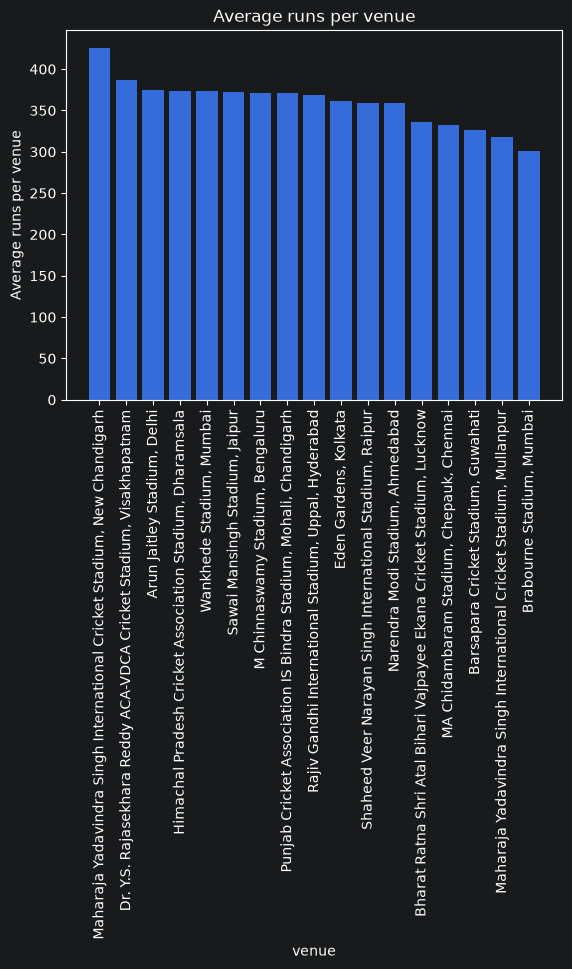

In [8]:
df["total_runs"]=df["team1_runs"]+df["team2_runs"]
avg=df.groupby("venue")["total_runs"].mean().sort_values(ascending=False)
print(avg)
plt.bar(avg.index,avg.values)
plt.title("Average runs per venue")
plt.xlabel("venue")
plt.ylabel("Average runs per venue")
plt.xticks(rotation=90)
plt.show()

toss_decision  toss_win
bat            False        42
               True         28
field          False       112
               True        118
dtype: int64
toss_decision
bat      40.000000
field    51.304348
Name: toss_win, dtype: float64


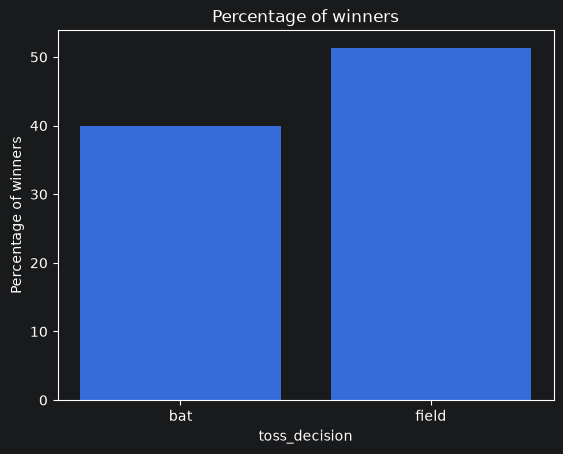

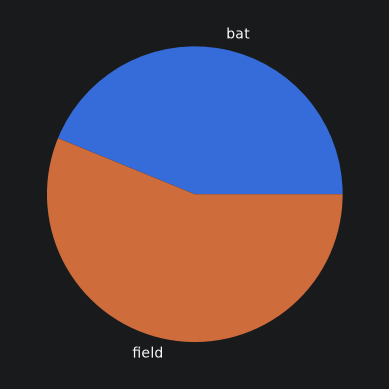

In [9]:
df["toss_win"]=df["toss_winner"]==df["winner"]
result=df.groupby(["toss_decision","toss_win"]).size()
print(result)
win_percent=df.groupby("toss_decision")["toss_win"].mean()*100
print(win_percent)
plt.bar(win_percent.index,win_percent.values)
plt.title("Percentage of winners")
plt.xlabel("toss_decision")
plt.ylabel("Percentage of winners")
plt.show()
plt.pie(win_percent.values,labels=win_percent.index)

season
2022    164.000000
2023    182.569412
2025    189.517203
2024    190.017930
2026    192.800987
Name: team1_runs, dtype: float64
highest inning score:  192.80098699381975
lowest inning score:  164.0
Index([2022, 2023, 2025, 2024, 2026], dtype='int64', name='season')


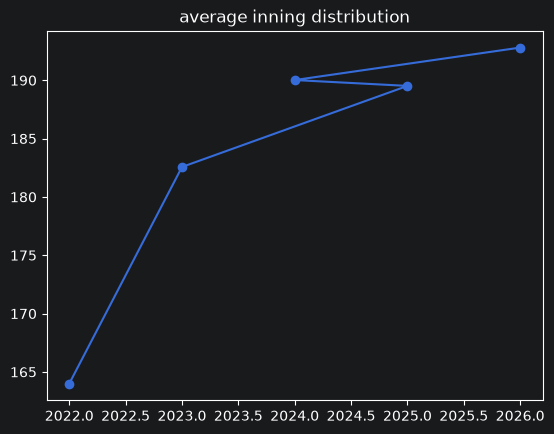

In [23]:
avg_inning_score=df.groupby("season")["team1_runs"].mean().sort_values()
print(avg_inning_score)
print("highest inning score: ",avg_inning_score.max())
print("lowest inning score: ",avg_inning_score.min())
plt.plot(avg_inning_score.index,avg_inning_score.values)
plt.title("average inning distribution")
print(avg_inning_score.index)
plt.scatter(x=avg_inning_score.index,y=avg_inning_score.values)
plt.show()

Rajasthan Royals               63
Gujarat Titans                 63
Punjab Kings                   61
Mumbai Indians                 61
Sunrisers Hyderabad            60
Chennai Super Kings            59
Delhi Capitals                 58
Lucknow Super Giants           58
Kolkata Knight Riders          55
Royal Challengers Bengaluru    46
Royal Challengers Bangalore    16
Name: count, dtype: int64
winner
Gujarat Titans                 49
Rajasthan Royals               29
Punjab Kings                   29
Royal Challengers Bengaluru    28
Mumbai Indians                 27
Kolkata Knight Riders          27
Sunrisers Hyderabad            27
Chennai Super Kings            26
Lucknow Super Giants           25
Delhi Capitals                 25
Royal Challengers Bangalore     8
Name: count, dtype: int64
300
[77.77777778 46.03174603 47.54098361 45.90163934 45.         45.76271186
 46.55172414 44.82758621 45.45454545 54.34782609 50.        ]
team1
Chennai Super Kings            185.285516
Delhi 

<Axes: >

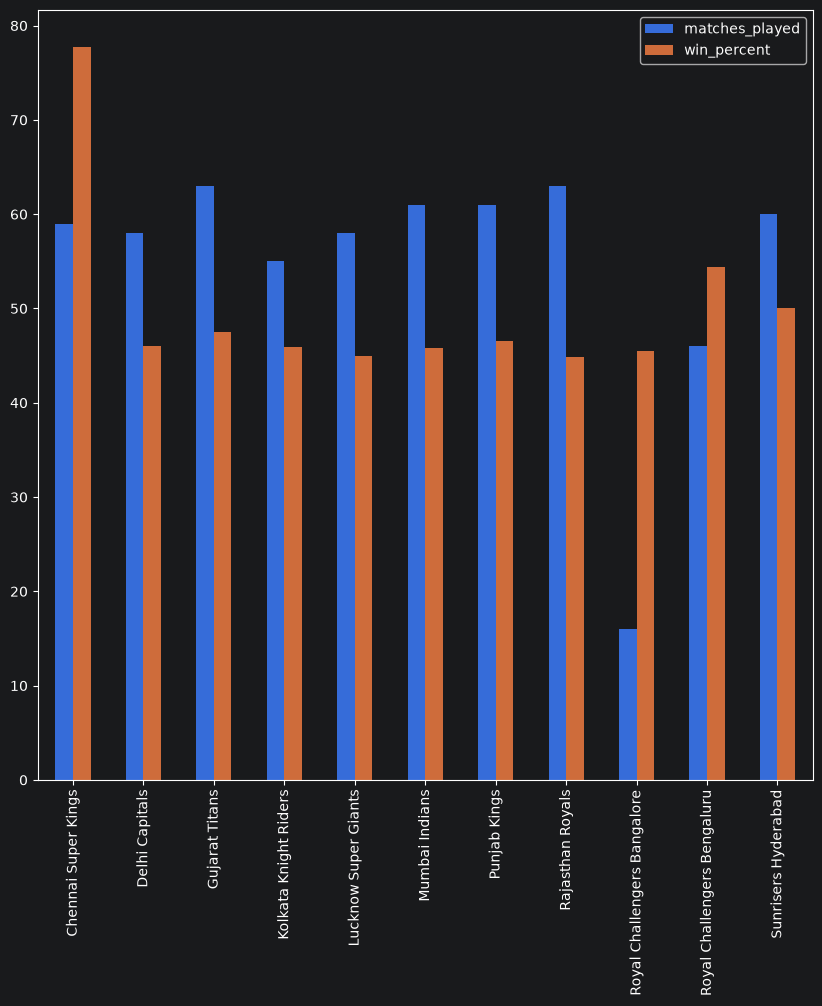

In [43]:
matches_played=pd.concat([df["team1"],df["team2"]]).value_counts()
print(matches_played)
total_win=df["winner"].value_counts()
print(total_win)
print(df.shape[0])
win_percent=(total_win.values/matches_played.values)*100
print(win_percent)
avg_runs=df.groupby("team1")["team1_runs"].mean()
print(avg_runs)
avg_wickets=df.groupby("team1")["team1_wickets"].mean()
print(avg_wickets)
dashboard=pd.DataFrame({
    "matches_played":matches_played,
    "win_percent":win_percent,
    "avg_runs":avg_runs,
    "avg_wickets":avg_wickets
})
fig,ax=plt.subplots(figsize=(10,10))
dashboard[["matches_played","win_percent"]].plot(kind="bar",ax=ax)

Index([], dtype='str')


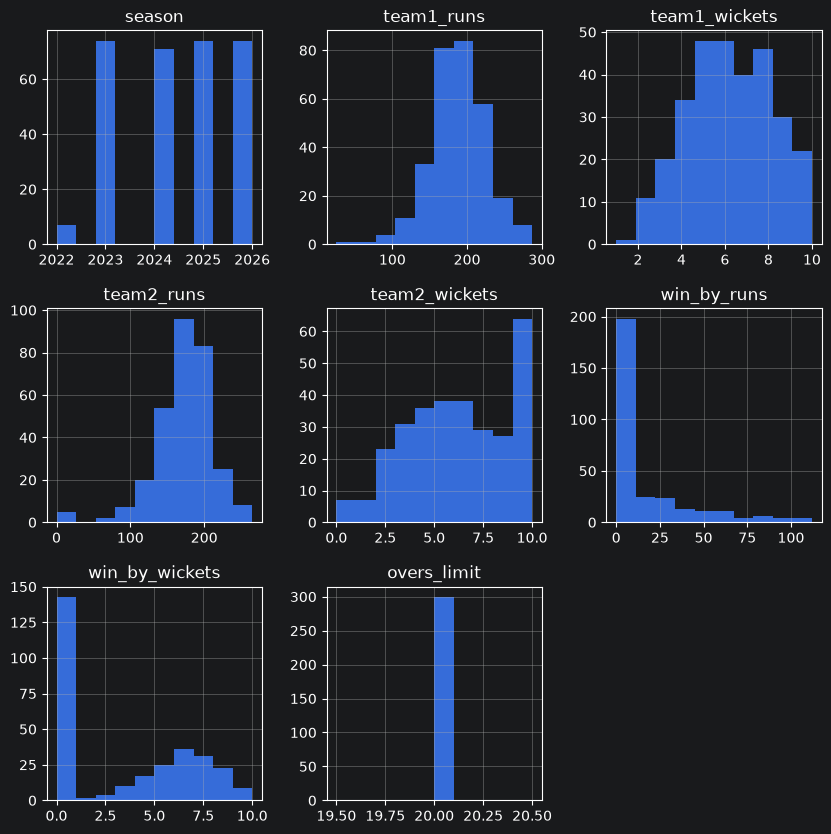

season:0 outliers
team1_runs:5 outliers
team1_wickets:0 outliers
team2_runs:7 outliers
team2_wickets:0 outliers
win_by_runs:25 outliers
win_by_wickets:0 outliers
overs_limit:0 outliers
Index([], dtype='str')


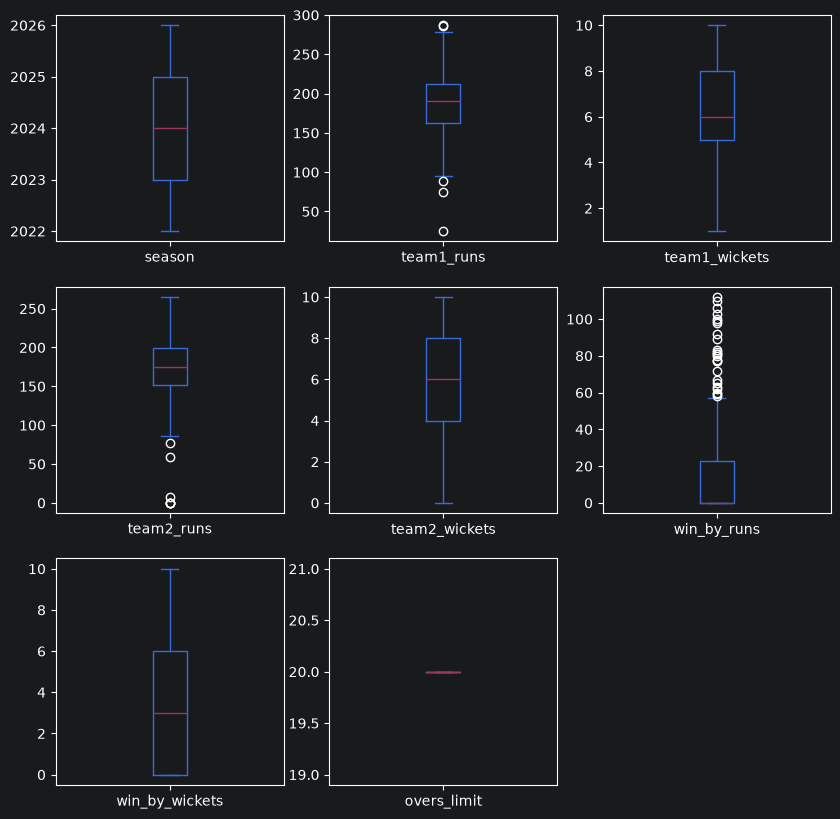

In [67]:
missing_col=df.columns[df.isnull().any()]
print(missing_col)
numeric_df=df.select_dtypes(include="number")
numeric_df.hist(figsize=(10,10),bins=10)
plt.show()
for cols in numeric_df:
    Q1=numeric_df[cols].quantile(0.25)
    Q3=numeric_df[cols].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outlier=numeric_df[(numeric_df[cols]<lower)|(numeric_df[cols]>upper)]
    print(f"{cols}:{len(outlier)} outliers")
numeric_df.plot(kind="box",subplots=True,figsize=(10,10),layout=(3,3))
df["team1_runs"]=df["team1_runs"].fillna(df["team1_runs"].median())
df["team2_runs"]=df["team2_runs"].fillna((df["team2_runs"].median()))
df["winner"]=df["winner"].fillna(df["winner"].mode()[0])
df["player_of_match"]=df["player_of_match"].fillna(df["player_of_match"].mode()[0])
print(missing_col)